In [ ]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
train_dir = "/content/drive/MyDrive/CNN Model/Lung Diseases/Lung Diseases/Train"

val_dir = "/content/drive/MyDrive/CNN Model/Lung Diseases/Lung Diseases/Val"

test_dir = "/content/drive/MyDrive/CNN Model/Lung Diseases/Lung Diseases/Test"

In [ ]:
import os

print("Train Classes:")
print(os.listdir(train_dir))

print("\nVal Classes:")
print(os.listdir(val_dir))

print("\nTest Classes:")
print(os.listdir(test_dir))

Train Classes:
['Tuberculosis', 'Pneumonia', 'Normal', 'Covid']

Val Classes:
['Covid', 'Tuberculosis', 'Normal', 'Pneumonia']

Test Classes:
['Tuberculosis', 'Normal', 'Pneumonia', 'Covid']


In [ ]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 12067 images belonging to 4 classes.
Found 1426 images belonging to 4 classes.
Found 1496 images belonging to 4 classes.


In [ ]:
print(train_generator.class_indices)

{'Covid': 0, 'Normal': 1, 'Pneumonia': 2, 'Tuberculosis': 3}


In [ ]:
print("Training Images:", train_generator.samples)
print("Validation Images:", val_generator.samples)
print("Testing Images:", test_generator.samples)

Training Images: 12067
Validation Images: 1426
Testing Images: 1496


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = train_generator.classes

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(classes),
    y=classes
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(4.626917177914111), 1: np.float64(3.4835450346420322), 2: np.float64(0.8068333779085317), 3: np.float64(0.4429882525697504)}


In [ ]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model

base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(512, activation='relu')(x)

x = BatchNormalization()(x)

x = Dropout(0.5)(x)

output = Dense(
    4,
    activation='softmax'
)(x)

model = Model(
    inputs=base_model.input,
    outputs=output
)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
checkpoint_path = "/content/drive/MyDrive/CNN Model/checkpoints"

import os
os.makedirs(checkpoint_path, exist_ok=True)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    filepath=checkpoint_path + "/best_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    verbose=1
)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights,
    callbacks=[
        checkpoint,
        early_stop,
        reduce_lr
    ]
)

Epoch 1/10
378/378 ━━━━━━━━━━━━━━━━━━━━ 0s 14s/step - accuracy: 0.5305 - loss: 1.0984 
Epoch 1: val_accuracy improved from None to 0.57293, saving model to /content/drive/MyDrive/CNN Model/checkpoints/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/CNN Model/checkpoints/best_model.keras
378/378 ━━━━━━━━━━━━━━━━━━━━ 5762s 15s/step - accuracy: 0.6104 - loss: 0.9260 - val_accuracy: 0.5729 - val_loss: 1.0224 - learning_rate: 1.0000e-04
Epoch 2/10
378/378 ━━━━━━━━━━━━━━━━━━━━ 0s 759ms/step - accuracy: 0.7083 - loss: 0.6996
Epoch 2: val_accuracy improved from 0.57293 to 0.74123, saving model to /content/drive/MyDrive/CNN Model/checkpoints/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/CNN Model/checkpoints/best_model.keras
378/378 ━━━━━━━━━━━━━━━━━━━━ 307s 813ms/step - accuracy: 0.7208 - loss: 0.6812 - val_accuracy: 0.7412 - val_loss: 0.6469 - learning_rate: 1.0000e-04
Epoch 3/10
377/378 ━━━━━━━━━━━━━━━━━━━━ 0s 759ms/step - accuracy: 0.7

In [ ]:
from tensorflow.keras.models import load_model

model = load_model(
    "/content/drive/MyDrive/CNN Model/checkpoints/best_model.keras"
)

In [ ]:
import pickle

with open(
    "/content/drive/MyDrive/CNN Model/history.pkl",
    "wb"
) as f:
    pickle.dump(history.history, f)

In [ ]:
test_loss, test_acc = model.evaluate(
    test_generator
)

print("Test Accuracy:", test_acc)

47/47 ━━━━━━━━━━━━━━━━━━━━ 653s 14s/step - accuracy: 0.7433 - loss: 0.6448
Test Accuracy: 0.7433155179023743


In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np

pred = model.predict(test_generator)

y_pred = np.argmax(pred, axis=1)

cm = confusion_matrix(
    test_generator.classes,
    y_pred
)

print(cm)

47/47 ━━━━━━━━━━━━━━━━━━━━ 50s 761ms/step
[[ 53   0   1   4]
 [  2 106   0   0]
 [  5 169 304   0]
 [193   4   6 649]]


In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        test_generator.classes,
        y_pred,
        target_names=test_generator.class_indices.keys()
    )
)

              precision    recall  f1-score   support

       Covid       0.21      0.91      0.34        58
      Normal       0.38      0.98      0.55       108
   Pneumonia       0.98      0.64      0.77       478
Tuberculosis       0.99      0.76      0.86       852

    accuracy                           0.74      1496
   macro avg       0.64      0.82      0.63      1496
weighted avg       0.91      0.74      0.79      1496



In [ ]:
model.save(
    "/content/drive/MyDrive/CNN Model/final_densenet.keras"
)

Model Testing

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving a.jpg to a.jpg


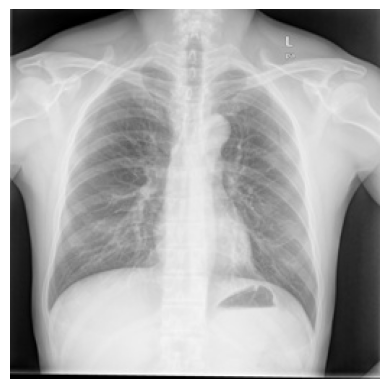

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = list(uploaded.keys())[0]

img = cv2.imread(image_path)

img_rgb = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2RGB
)

plt.imshow(img_rgb)
plt.axis("off")
plt.show()

In [ ]:
IMG_SIZE = 224

img_resized = cv2.resize(
    img_rgb,
    (IMG_SIZE, IMG_SIZE)
)

input_image = img_resized / 255.0

input_image = np.expand_dims(
    input_image,
    axis=0
)

In [ ]:
prediction = model.predict(
    input_image
)

classes = [
    "Covid",
    "Normal",
    "Pneumonia",
    "Tuberculosis"
]

predicted_class = np.argmax(
    prediction
)

disease = classes[predicted_class]

confidence = np.max(prediction) * 100

print(
    f"Disease: {disease}"
)

print(
    f"Confidence: {confidence:.2f}%"
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step
Disease: Tuberculosis
Confidence: 92.29%


In [ ]:
for i, cls in enumerate(classes):
    print(
        f"{cls}: {prediction[0][i]*100:.2f}%"
    )

Covid: 7.50%
Normal: 0.18%
Pneumonia: 0.03%
Tuberculosis: 92.29%


In [ ]:
import tensorflow as tf

last_conv_layer = model.get_layer(
    "conv5_block16_concat"
)

grad_model = tf.keras.models.Model(
    [model.inputs],
    [
        last_conv_layer.output,
        model.output
    ]
)

In [ ]:
import numpy as np
with tf.GradientTape() as tape:

    conv_outputs, predictions = grad_model(
        input_image
    )

    class_idx = tf.argmax(
        predictions[0]
    )

    loss = predictions[:, class_idx]

grads = tape.gradient(
    loss,
    conv_outputs
)

pooled_grads = tf.reduce_mean(
    grads,
    axis=(0,1,2)
)

conv_outputs = conv_outputs[0]

heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]

heatmap = tf.squeeze(
    heatmap
)

heatmap = np.maximum(
    heatmap,
    0
)

heatmap /= np.max(
    heatmap
)

# The .numpy() call is removed here as `heatmap` is already a numpy array after np.maximum()

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


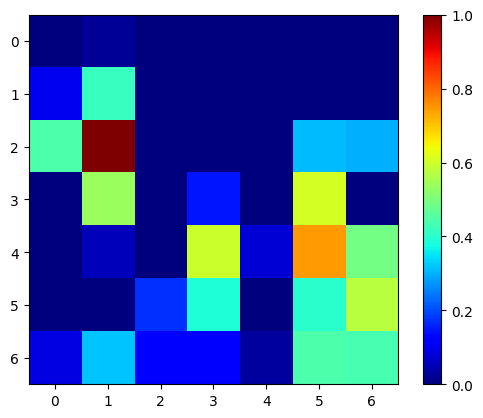

In [ ]:
plt.imshow(
    heatmap,
    cmap='jet'
)

plt.colorbar()
plt.show()

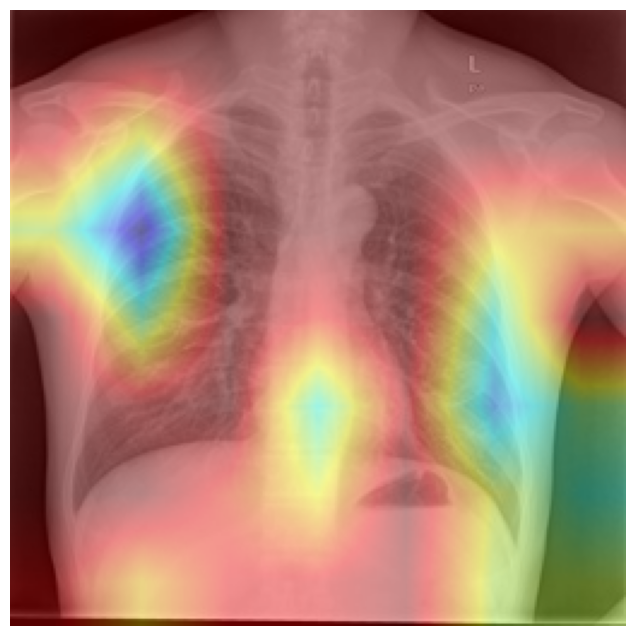

In [ ]:
heatmap = cv2.resize(
    heatmap,
    (
        img_rgb.shape[1],
        img_rgb.shape[0]
    )
)

heatmap_uint8 = np.uint8(
    255 * heatmap
)

heatmap_color = cv2.applyColorMap(
    heatmap_uint8,
    cv2.COLORMAP_JET
)

overlay = cv2.addWeighted(
    img_rgb,
    0.6,
    heatmap_color,
    0.4,
    0
)

plt.figure(figsize=(8,8))
plt.imshow(overlay)
plt.axis('off')
plt.show()

In [ ]:
threshold = 180

binary_mask = cv2.threshold(
    heatmap_uint8,
    threshold,
    255,
    cv2.THRESH_BINARY
)[1]

array([[[ 89,  89,  89],
        [ 53,  53,  53],
        [ 34,  34,  34],
        ...,
        [ 77,  77,  77],
        [ 82,  82,  82],
        [ 85,  85,  85]],

       [[ 86,  86,  86],
        [ 50,  50,  50],
        [ 31,  31,  31],
        ...,
        [ 73,  73,  73],
        [ 78,  78,  78],
        [ 80,  80,  80]],

       [[ 84,  84,  84],
        [ 48,  48,  48],
        [ 29,  29,  29],
        ...,
        [ 70,  70,  70],
        [ 74,  74,  74],
        [ 77,  77,  77]],

       ...,

       [[  0,   0,   0],
        [  0,   0,   0],
        [  1,   1,   1],
        ...,
        [156, 156, 156],
        [161, 161, 161],
        [167, 167, 167]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [194, 194, 194],
        [194, 194, 194],
        [199, 199, 199]],

       [[  1,   1,   1],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [107, 107, 107],
        [109, 109, 109],
        [111, 111, 111]]], dtype=uint8)
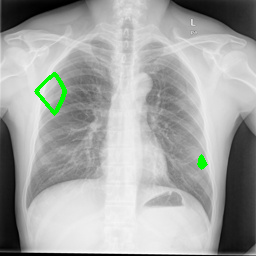

In [ ]:
contours, _ = cv2.findContours(
    binary_mask,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

outlined = img_rgb.copy()

cv2.drawContours(
    outlined,
    contours,
    -1,
    (0,255,0),
    3
)

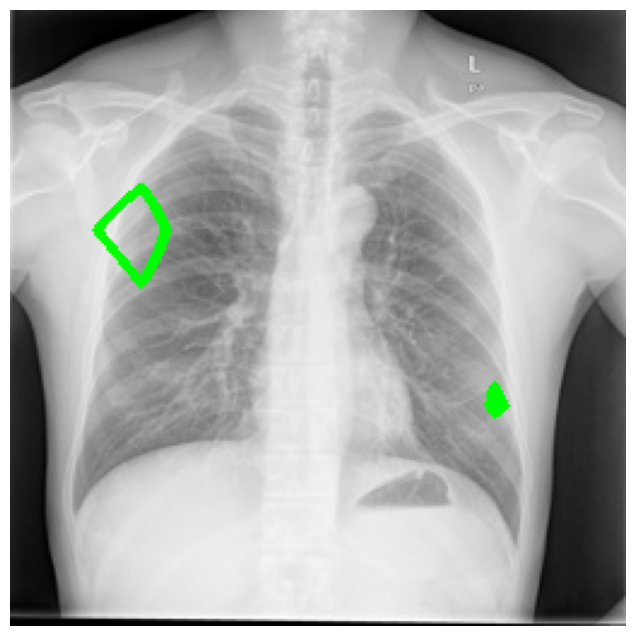

In [ ]:
plt.figure(figsize=(8,8))

plt.imshow(outlined)

plt.axis("off")

plt.show()

XAI

In [ ]:
!pip install shap

In [ ]:
prompt = f"""
Disease Prediction: {disease}

Confidence: {confidence}

Affected Region:
Upper Right Lung

Generate a clinical explanation
for a doctor.
"""

RUN CASE 2

In [ ]:
from google.colab import files

uploaded = files.upload()

image_path = list(uploaded.keys())[0]

print("Uploaded:", image_path)

Saving 1.CXRCTThoraximagesofCOVID-19fromSingapore.pdf-003-fig4a.png to 1.CXRCTThoraximagesofCOVID-19fromSingapore.pdf-003-fig4a.png
Uploaded: 1.CXRCTThoraximagesofCOVID-19fromSingapore.pdf-003-fig4a.png


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

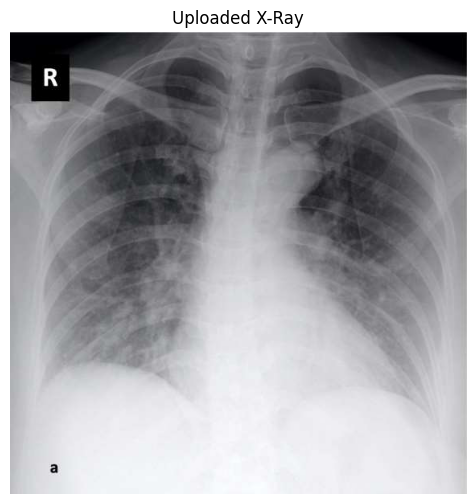

In [ ]:
IMG_SIZE = 224

img_bgr = cv2.imread(image_path)

img_rgb = cv2.cvtColor(
    img_bgr,
    cv2.COLOR_BGR2RGB
)

img_resized = cv2.resize(
    img_rgb,
    (IMG_SIZE, IMG_SIZE)
)

input_image = img_resized.astype("float32") / 255.0

input_image = np.expand_dims(
    input_image,
    axis=0
)

plt.figure(figsize=(6,6))
plt.imshow(img_rgb)
plt.axis("off")
plt.title("Uploaded X-Ray")
plt.show()

In [ ]:
classes = [
    "Covid",
    "Normal",
    "Pneumonia",
    "Tuberculosis"
]

pred = model.predict(input_image)

predicted_index = np.argmax(pred)

disease = classes[predicted_index]

confidence = pred[0][predicted_index] * 100

print("Prediction:", disease)
print("Confidence:", round(confidence,2), "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Prediction: Covid
Confidence: 98.81 %


In [ ]:
for i, cls in enumerate(classes):
    print(
        f"{cls}: {pred[0][i]*100:.2f}%"
    )

Covid: 98.81%
Normal: 0.03%
Pneumonia: 0.02%
Tuberculosis: 1.14%


In [ ]:
last_conv_layer_name = "conv5_block16_concat"

In [ ]:
grad_model = tf.keras.models.Model(
    [model.inputs],
    [
        model.get_layer(
            last_conv_layer_name
        ).output,
        model.output
    ]
)

In [ ]:
with tf.GradientTape() as tape:

    conv_outputs, predictions = grad_model(
        input_image
    )

    class_idx = tf.argmax(
        predictions[0]
    )

    loss = predictions[:, class_idx]

grads = tape.gradient(
    loss,
    conv_outputs
)

pooled_grads = tf.reduce_mean(
    grads,
    axis=(0,1,2)
)

conv_outputs = conv_outputs[0]

heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]

heatmap = tf.squeeze(
    heatmap
)

heatmap = np.maximum(
    heatmap,
    0
)

heatmap /= np.max(
    heatmap
)

# Removed the redundant .numpy() call as heatmap is already a numpy array

In [ ]:
with tf.GradientTape() as tape:

    conv_outputs, predictions = grad_model(
        input_image
    )

    class_idx = tf.argmax(
        predictions[0]
    )

    loss = predictions[:, class_idx]

grads = tape.gradient(
    loss,
    conv_outputs
)

pooled_grads = tf.reduce_mean(
    grads,
    axis=(0,1,2)
)

conv_outputs = conv_outputs[0]

heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]

heatmap = tf.squeeze(
    heatmap
)

heatmap = np.maximum(
    heatmap,
    0
)

heatmap /= np.max(
    heatmap
)

# The .numpy() call is removed here as `heatmap` is already a numpy array

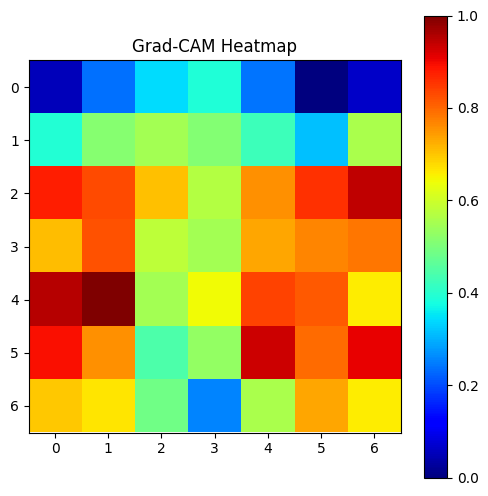

In [ ]:
plt.figure(figsize=(6,6))

plt.imshow(
    heatmap,
    cmap='jet'
)

plt.colorbar()

plt.title("Grad-CAM Heatmap")

plt.show()

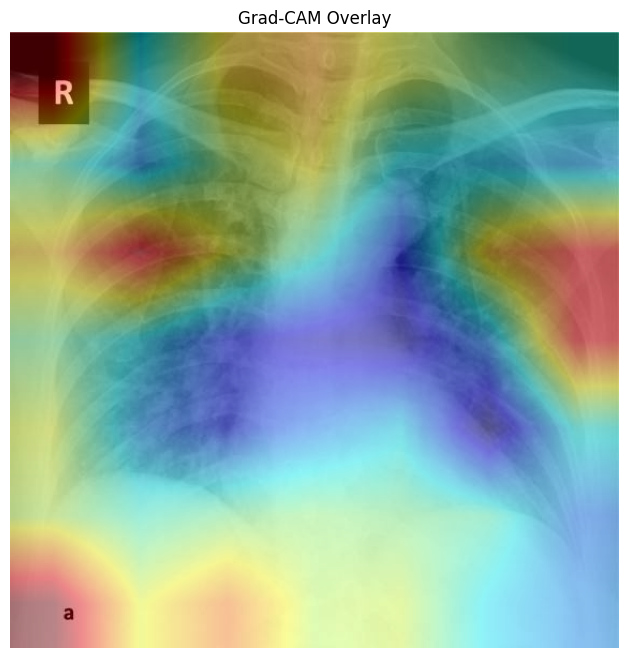

In [ ]:
heatmap_resized = cv2.resize(
    heatmap,
    (
        img_rgb.shape[1],
        img_rgb.shape[0]
    )
)

heatmap_uint8 = np.uint8(
    heatmap_resized * 255
)

heatmap_color = cv2.applyColorMap(
    heatmap_uint8,
    cv2.COLORMAP_JET
)

overlay = cv2.addWeighted(
    img_rgb,
    0.6,
    heatmap_color,
    0.4,
    0
)

plt.figure(figsize=(8,8))

plt.imshow(overlay)

plt.axis("off")

plt.title("Grad-CAM Overlay")

plt.show()

[[7.5027347e-02 1.8126644e-03 2.9853720e-04 9.2286140e-01]]


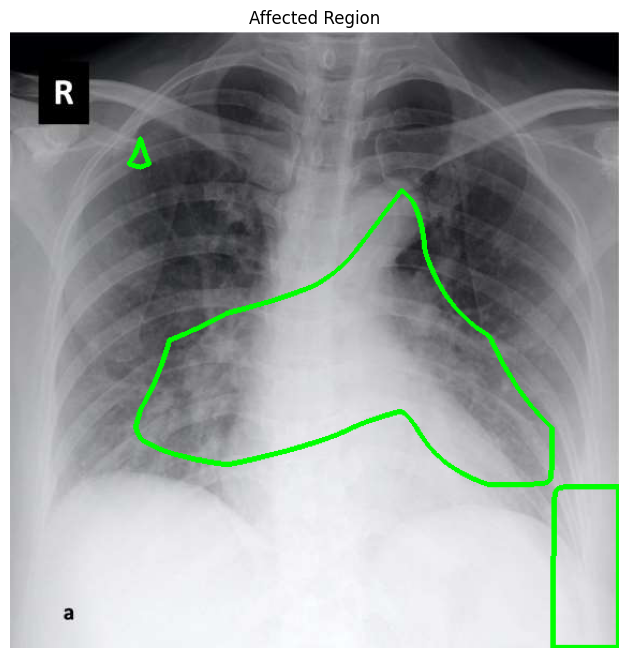

In [ ]:
threshold = 180

binary_mask = cv2.threshold(
    heatmap_uint8,
    threshold,
    255,
    cv2.THRESH_BINARY
)[1]

contours, _ = cv2.findContours(
    binary_mask,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

outlined = img_rgb.copy()

cv2.drawContours(
    outlined,
    contours,
    -1,
    (0,255,0),
    3
)
print(prediction)

plt.figure(figsize=(8,8))

plt.imshow(outlined)

plt.axis("off")


plt.title("Affected Region")

plt.show()

In [ ]:
affected_pixels = np.sum(
    binary_mask > 0
)

total_pixels = binary_mask.size

affected_percentage = (
    affected_pixels /
    total_pixels
) * 100

print(
    "Affected Area:",
    round(
        affected_percentage,
        2
    ),
    "%"
)

Affected Area: 19.19 %


In [ ]:
region = "lung field"

if affected_percentage < 5:
    severity = "minimal"

elif affected_percentage < 15:
    severity = "mild"

elif affected_percentage < 30:
    severity = "moderate"

else:
    severity = "extensive"

report = f"""
AI Prediction: {disease}

Confidence Score:
{confidence:.2f}%

Affected Area:
{affected_percentage:.2f}%

Severity Assessment:
{severity}

Explainable AI Summary:
The DenseNet121 model identified image
patterns associated with {disease}.
Grad-CAM highlighted approximately
{affected_percentage:.2f}% of the lung
region as influential to the prediction.
The activation intensity suggests a
{severity} level of abnormality.
Clinical review by a qualified healthcare
professional is recommended.
"""

print(report)


AI Prediction: Covid

Confidence Score:
98.81%

Affected Area:
19.19%

Severity Assessment:
moderate

Explainable AI Summary:
The DenseNet121 model identified image
patterns associated with Covid.
Grad-CAM highlighted approximately
19.19% of the lung
region as influential to the prediction.
The activation intensity suggests a
moderate level of abnormality.
Clinical review by a qualified healthcare
professional is recommended.

